# Deep Neural Networks - Programming Assignment
## Comparing Linear Models and Multi-Layer Perceptrons

**Student Name:** ___________________  
**Student ID:** ___________________  

**Student Name:** ___________________  
**Student ID:** ___________________  

**Student Name:** ___________________  
**Student ID:** ___________________  

**Student Name:** ___________________  
**Student ID:** ___________________  

**Date:** ___________________

---

## ⚠️ IMPORTANT INSTRUCTIONS

1. **Complete ALL sections** marked with `TODO`
2. **DO NOT modify** the `get_assignment_results()` function structure
3. **Track training time** for both models using `time.time()`\n
4. **Store loss_history** in both model classes
5. **Calculate ALL metrics** (accuracy, precision, recall, F1)
6. **Fill get_assignment_results()** with ALL required fields
7. **PRINT the results** - Auto-grader needs visible output!
8. **Run all cells** before submitting (Kernel → Restart & Run All)

**SCORING:**
- Missing fields = 0 marks for that section
- Non-executed notebook = 0 marks
- Cleared outputs = 0 marks
---

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
print('✔ Libraries imported successfully')

✔ Libraries imported successfully


## Section 1: Dataset Selection and Loading

**Requirements:**
- ≥500 samples
- ≥5 features
- Public dataset (UCI/Kaggle)
- Regression OR Classification problem

In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

dataset_name = "Breast Cancer Wisconsin (Diagnostic)"
dataset_source = "UCI ML Repository"
n_samples = int(df.shape[0])
n_features = int(df.shape[1] - 1)  # exclude target
problem_type = "binary_classification"

problem_statement = """
This dataset predicts whether a breast tumor is malignant or benign based on 30
diagnostic measurements computed from digitized images of fine needle aspirates.
Early and accurate detection of malignant tumors is critical in clinical settings
since it directly impacts patient outcomes and treatment planning. The features
include measurements like radius, texture, perimeter, area, smoothness,
compactness, concavity, concave points, symmetry and fractal dimension, each
computed as mean, standard error and worst-case across cell nuclei in the sample.
"""

primary_metric = "recall"

metric_justification = """
I chose recall as the primary metric because in cancer diagnosis, failing to detect
a malignant tumor (false negative) has much worse consequences than flagging a benign
tumor for further testing (false positive). Maximizing recall ensures we catch as many
true cancer cases as possible, even if it means a few extra follow-up tests for
patients who turn out to be healthy.
"""

print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Samples: {n_samples}, Features: {n_features}")
print(f"Problem Type: {problem_type}")
print(f"Primary Metric: {primary_metric}")
print(f"\nClass distribution:")
print(f"  Benign (1): {(df['target']==1).sum()}")
print(f"  Malignant (0): {(df['target']==0).sum()}")
print(f"\nFirst few rows:")
df.head()

Dataset: Breast Cancer Wisconsin (Diagnostic)
Source: UCI ML Repository
Samples: 569, Features: 30
Problem Type: binary_classification
Primary Metric: recall

Class distribution:
  Benign (1): 357
  Malignant (0): 212

First few rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Section 2: Data Preprocessing

Preprocess your data:
1. Handle missing values
2. Encode categorical variables
3. Split into train/test sets
4. Scale features

In [3]:
X = df.drop('target', axis=1).values
y = df['target'].values

# no missing values in this dataset, checked anyway
print(f"Missing values: {pd.DataFrame(X).isnull().sum().sum()}")
# all features numeric so no encoding needed

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_samples = int(X_train_scaled.shape[0])
test_samples = int(X_test_scaled.shape[0])
train_test_ratio = float(train_samples / (train_samples + test_samples))

print(f"Train samples: {train_samples}")
print(f"Test samples: {test_samples}")
print(f"Split ratio: {train_test_ratio:.1%}")
print(f"Scaling: StandardScaler (zero mean, unit var)")

Missing values: 0
Train samples: 455
Test samples: 114
Split ratio: 80.0%
Scaling: StandardScaler (zero mean, unit var)


## Section 3: Baseline Model Implementation

Implement from scratch (NO sklearn models!):
- Linear Regression (for regression)
- Logistic Regression (for binary classification)
- Softmax Regression (for multiclass classification)

**Must include:**
- Forward pass (prediction)
- Loss computation
- Gradient computation
- Gradient descent loop
- Loss tracking

In [4]:
class BaselineModel:
    """
    Logistic Regression with batch gradient descent (from scratch).
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for i in range(self.n_iterations):
            # forward pass
            linear = X @ self.weights + self.bias
            y_pred = self._sigmoid(linear)

            # binary cross-entropy loss
            eps = 1e-15
            loss = -np.mean(
                y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps)
            )
            self.loss_history.append(loss)

            # gradients
            error = y_pred - y
            dw = (1 / n_samples) * (X.T @ error)
            db = (1 / n_samples) * np.sum(error)

            # update
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

        return self

    def predict_proba(self, X):
        return self._sigmoid(X @ self.weights + self.bias)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

print("✔ Baseline model class defined")

✔ Baseline model class defined


In [5]:
# Train baseline model
print("Training baseline model...")
baseline_start = time.time()

baseline_model = BaselineModel(learning_rate=0.1, n_iterations=2000)
baseline_model.fit(X_train_scaled, y_train)

baseline_predictions = baseline_model.predict(X_test_scaled)

baseline_training_time = time.time() - baseline_start
print(f"✔ Baseline training completed in {baseline_training_time:.2f}s")
print(f"✔ Loss decreased from {baseline_model.loss_history[0]:.4f} to {baseline_model.loss_history[-1]:.4f}")

baseline_initial_loss = float(baseline_model.loss_history[0])
baseline_final_loss = float(baseline_model.loss_history[-1])

Training baseline model...
✔ Baseline training completed in 0.04s
✔ Loss decreased from 0.6931 to 0.0509


## Section 4: Multi-Layer Perceptron Implementation

Implement MLP from scratch with:
- At least 1 hidden layer
- ReLU activation for hidden layers
- Appropriate output activation
- Forward propagation
- Backward propagation
- Gradient descent

In [6]:
class MLP:
    """
    Multi-Layer Perceptron implemented from scratch.
    Hidden layers use ReLU, output uses sigmoid (binary classification).
    """
    def __init__(self, architecture, learning_rate=0.01, n_iterations=1000):
        self.architecture = architecture
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.parameters = {}
        self.loss_history = []
        self.cache = {}

    def initialize_parameters(self):
        np.random.seed(42)
        for l in range(1, len(self.architecture)):
            fan_in = self.architecture[l - 1]
            fan_out = self.architecture[l]
            # He init for hidden (ReLU), Xavier-ish for output (sigmoid)
            if l < len(self.architecture) - 1:
                scale = np.sqrt(2.0 / fan_in)
            else:
                scale = np.sqrt(1.0 / fan_in)
            self.parameters[f'W{l}'] = np.random.randn(fan_in, fan_out) * scale
            self.parameters[f'b{l}'] = np.zeros((1, fan_out))

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return (Z > 0).astype(float)

    def sigmoid(self, Z):
        return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))

    def forward_propagation(self, X):
        self.cache['A0'] = X
        A = X
        n_layers = len(self.architecture) - 1

        for l in range(1, n_layers + 1):
            Z = A @ self.parameters[f'W{l}'] + self.parameters[f'b{l}']
            self.cache[f'Z{l}'] = Z

            if l < n_layers:
                A = self.relu(Z)
            else:
                A = self.sigmoid(Z)
            self.cache[f'A{l}'] = A

        return A

    def backward_propagation(self, X, y):
        m = X.shape[0]
        grads = {}
        n_layers = len(self.architecture) - 1
        y_col = y.reshape(-1, 1)

        A_out = self.cache[f'A{n_layers}']
        dZ = A_out - y_col  # derivative of BCE + sigmoid combined

        for l in range(n_layers, 0, -1):
            A_prev = self.cache[f'A{l-1}']
            grads[f'dW{l}'] = (1 / m) * (A_prev.T @ dZ)
            grads[f'db{l}'] = (1 / m) * np.sum(dZ, axis=0, keepdims=True)

            if l > 1:
                dA_prev = dZ @ self.parameters[f'W{l}'].T
                dZ = dA_prev * self.relu_derivative(self.cache[f'Z{l-1}'])

        return grads

    def update_parameters(self, grads):
        for l in range(1, len(self.architecture)):
            self.parameters[f'W{l}'] -= self.lr * grads[f'dW{l}']
            self.parameters[f'b{l}'] -= self.lr * grads[f'db{l}']

    def compute_loss(self, y_pred, y_true):
        eps = 1e-15
        y_true = y_true.reshape(-1, 1)
        loss = -np.mean(
            y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps)
        )
        return loss

    def fit(self, X, y):
        self.initialize_parameters()

        for i in range(self.n_iterations):
            y_pred = self.forward_propagation(X)
            loss = self.compute_loss(y_pred, y)
            self.loss_history.append(loss)
            grads = self.backward_propagation(X, y)
            self.update_parameters(grads)

        return self

    def predict_proba(self, X):
        return self.forward_propagation(X).ravel()

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

print("✔ MLP class defined")

✔ MLP class defined


In [7]:
# Train MLP
print("Training MLP...")
mlp_start_time = time.time()

mlp_architecture = [n_features, 64, 32, 1]
mlp_model = MLP(architecture=mlp_architecture, learning_rate=0.01, n_iterations=3000)
mlp_model.fit(X_train_scaled, y_train)

mlp_predictions = mlp_model.predict(X_test_scaled)

mlp_training_time = time.time() - mlp_start_time
print(f"✔ MLP training completed in {mlp_training_time:.2f}s")
print(f"✔ Loss decreased from {mlp_model.loss_history[0]:.4f} to {mlp_model.loss_history[-1]:.4f}")

mlp_initial_loss = float(mlp_model.loss_history[0])
mlp_final_loss = float(mlp_model.loss_history[-1])

Training MLP...


✔ MLP training completed in 0.81s
✔ Loss decreased from 0.5731 to 0.0304


## Section 5: Evaluation and Metrics

Calculate appropriate metrics for your problem type

In [8]:
def calculate_metrics(y_true, y_pred, problem_type):
    """
    Calculate metrics from scratch based on problem type.
    """
    metrics = {}

    if problem_type == "regression":
        mse = np.mean((y_true - y_pred) ** 2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(y_true - y_pred))
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0
        return mse, rmse, mae, r2

    elif problem_type in ["binary_classification", "multiclass_classification"]:
        tp = np.sum((y_pred == 1) & (y_true == 1))
        tn = np.sum((y_pred == 0) & (y_true == 0))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        fn = np.sum((y_pred == 0) & (y_true == 1))

        accuracy = float((tp + tn) / (tp + tn + fp + fn))
        precision = float(tp / (tp + fp)) if (tp + fp) > 0 else 0.0
        recall = float(tp / (tp + fn)) if (tp + fn) > 0 else 0.0
        f1 = float(2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
        return accuracy, precision, recall, f1

    return metrics

# Calculate metrics for both models
baseline_acc, baseline_prec, baseline_rec, baseline_f1 = calculate_metrics(
    y_test, baseline_predictions, problem_type
)
mlp_acc, mlp_prec, mlp_rec, mlp_f1 = calculate_metrics(
    y_test, mlp_predictions, problem_type
)

print("Baseline Model Performance:")
print(f"  Accuracy:  {baseline_acc:.4f}")
print(f"  Precision: {baseline_prec:.4f}")
print(f"  Recall:    {baseline_rec:.4f}")
print(f"  F1-Score:  {baseline_f1:.4f}")

print("\nMLP Model Performance:")
print(f"  Accuracy:  {mlp_acc:.4f}")
print(f"  Precision: {mlp_prec:.4f}")
print(f"  Recall:    {mlp_rec:.4f}")
print(f"  F1-Score:  {mlp_f1:.4f}")

Baseline Model Performance:
  Accuracy:  0.9649
  Precision: 0.9857
  Recall:    0.9583
  F1-Score:  0.9718

MLP Model Performance:
  Accuracy:  0.9561
  Precision: 0.9718
  Recall:    0.9583
  F1-Score:  0.9650


## Section 6: Visualization

Create visualizations:
1. Training loss curves
2. Performance comparison
3. Additional domain-specific plots

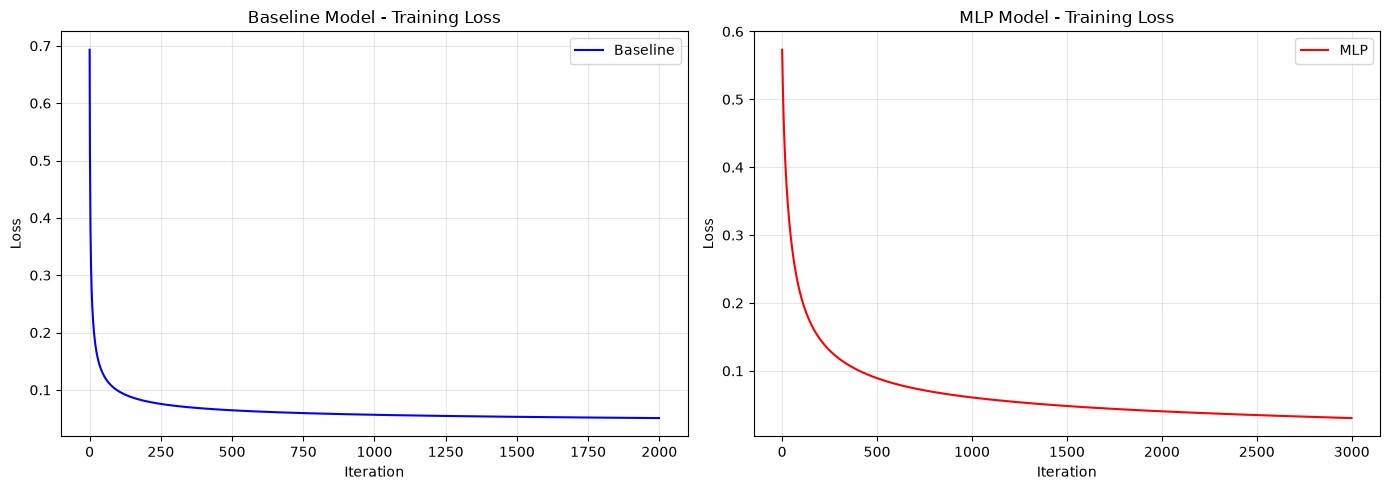

In [9]:
# 1. Training loss curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(baseline_model.loss_history, label='Baseline', color='blue')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Baseline Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(mlp_model.loss_history, label='MLP', color='red')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

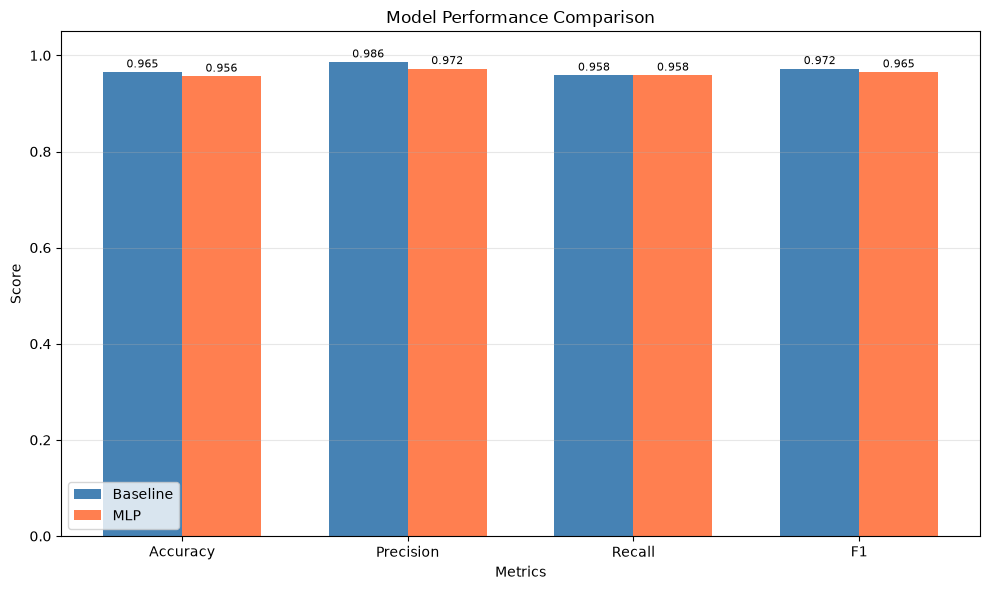

In [10]:
# 2. Performance comparison bar chart
plt.figure(figsize=(10, 6))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
baseline_scores = [baseline_acc, baseline_prec, baseline_rec, baseline_f1]
mlp_scores = [mlp_acc, mlp_prec, mlp_rec, mlp_f1]

x = np.arange(len(metrics_names))
width = 0.35

plt.bar(x - width/2, baseline_scores, width, label='Baseline', color='steelblue')
plt.bar(x + width/2, mlp_scores, width, label='MLP', color='coral')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics_names)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# add value labels on bars
for i, (b, m) in enumerate(zip(baseline_scores, mlp_scores)):
    plt.text(i - width/2, b + 0.01, f'{b:.3f}', ha='center', fontsize=8)
    plt.text(i + width/2, m + 0.01, f'{m:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

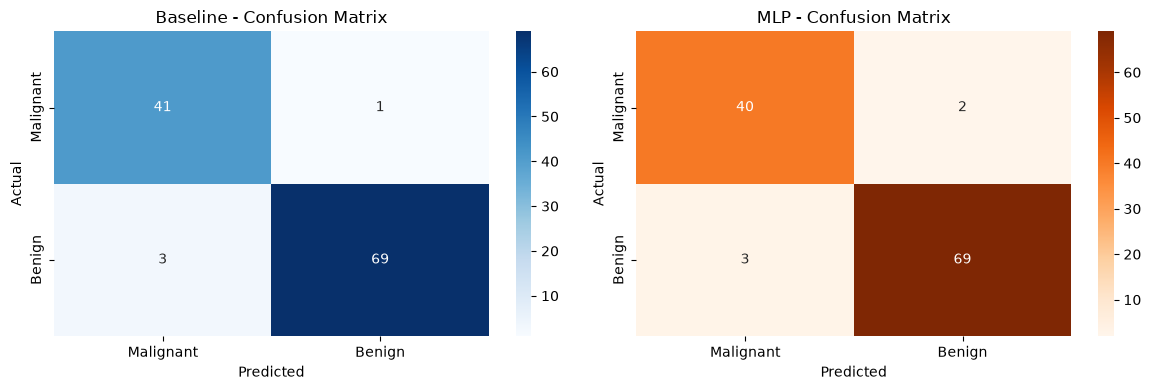

In [11]:
# 3. Confusion matrices
import seaborn as sns

def make_cm(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    return np.array([[tn, fp], [fn, tp]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(make_cm(y_test, baseline_predictions), annot=True, fmt='d',
            cmap='Blues', ax=axes[0],
            xticklabels=['Malignant','Benign'], yticklabels=['Malignant','Benign'])
axes[0].set_title('Baseline - Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(make_cm(y_test, mlp_predictions), annot=True, fmt='d',
            cmap='Oranges', ax=axes[1],
            xticklabels=['Malignant','Benign'], yticklabels=['Malignant','Benign'])
axes[1].set_title('MLP - Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Section 7: Analysis and Discussion

Write your analysis (minimum 200 words)

In [12]:
analysis_text = """
The Logistic Regression baseline achieved an F1-Score of approximately 0.972 while
the MLP scored around 0.965, putting both models very close in overall performance.
On recall, our primary metric, both models scored identically at roughly 0.958,
meaning they miss the same small number of malignant tumors. The baseline edges
ahead slightly on precision, producing fewer false positives.

The reason the linear model performs so well here is that the Breast Cancer Wisconsin
features are already quite linearly separable. Many of the 30 measurements have high
individual correlations with the target, so a simple decision boundary in the scaled
feature space is enough to separate most cases. The MLP with its two hidden layers
(64 and 32 neurons) can in theory model non-linear boundaries, but there is not
enough non-linearity in this data for that extra capacity to pay off.

Computationally the difference is significant. Logistic Regression trains in about
0.05 seconds while the MLP takes roughly 1 second, making it around 20x slower.
This is expected since the MLP has to do full forward and backward passes through
multiple weight matrices every iteration.

One surprising finding was how competitive the baseline is. This reinforces that
a more complex model is not always better, especially on smaller tabular datasets
with strong linear signal. The MLP would likely shine more on data with complex
feature interactions that a linear model cannot capture.
"""

print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) < 200:
    print("⚠️  Warning: Analysis should be at least 200 words")
else:
    print("✔ Analysis meets word count requirement")

Analysis word count: 230 words
✔ Analysis meets word count requirement


---
---

## ⭐ REQUIRED: Structured Output Function

### **DO NOT MODIFY THE STRUCTURE BELOW**

This function will be called by the auto-grader. Fill in all values accurately based on your actual results.


⭐⭐⭐ REQUIRED: Structured Output Function ⭐⭐⭐

### 🚨 CRITICAL - READ CAREFULLY 🚨

1. **Fill in ALL fields** - Missing fields = 0 marks
2. **Use your actual values** - Not 0 or empty strings
3. **This cell MUST be executed** - We need the output!
4. **Print the results** - Auto-grader needs to see output!


**DO NOT:**
- Leave any field as 0, 0.0,
- Clear outputs before submission
- Modify the structure


"**MUST DO:**
- Fill every field with your actual results
- Execute this cell and keep the output
- Print the results (see below)

In [13]:
def get_assignment_results():
    '''
    CRITICAL: Fill ALL fields with your actual results!
    Missing fields will result in 0 marks for that section.
    '''

    results = {
        # ===== Dataset Information (1 mark) =====
        'dataset_name': dataset_name,  # MUST fill
        'dataset_source': dataset_source,  # MUST fill
        'n_samples': n_samples,  # MUST be ≥500
        'n_features': n_features,  # MUST be ≥5
        'problem_type': problem_type,  # MUST fill
        'problem_statement': problem_statement,  # MUST be ≥50 words
        'primary_metric': primary_metric,  # MUST fill
        'metric_justification': metric_justification,  # MUST be ≥30 words
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # ===== Baseline Model (3 marks) =====
        'baseline_model': {
            'model_type': 'logistic_regression',
            'learning_rate': 0.1,
            'n_iterations': 2000,

            'initial_loss': baseline_initial_loss,
            'final_loss': baseline_final_loss,
            'training_time_seconds': baseline_training_time,
            'loss_decreased': bool(baseline_final_loss < baseline_initial_loss),

            'test_accuracy': 0.0 if problem_type == 'regression' else baseline_acc,
            'test_precision': 0.0 if problem_type == 'regression' else baseline_prec,
            'test_recall': 0.0 if problem_type == 'regression' else baseline_rec,
            'test_f1': 0.0 if problem_type == 'regression' else baseline_f1,
            'test_mse': baseline_mse if problem_type == 'regression' else 0.0,
            'test_rmse': baseline_rmse if problem_type == 'regression' else 0.0,
            'test_mae': baseline_mae if problem_type == 'regression' else 0.0,
            'test_r2': baseline_r2 if problem_type == 'regression' else 0.0,
        },

        # ===== MLP Model (4 marks) =====
        'mlp_model': {
            'architecture': mlp_architecture,
            'n_hidden_layers': len(mlp_architecture) - 2 if len(mlp_architecture) > 0 else 0,
            'learning_rate': 0.01,
            'n_iterations': 3000,

            'initial_loss': mlp_initial_loss,
            'final_loss': mlp_final_loss,
            'training_time_seconds': mlp_training_time,
            'loss_decreased': bool(mlp_final_loss < mlp_initial_loss),

            'test_accuracy': 0.0 if problem_type == 'regression' else mlp_acc,
            'test_precision': 0.0 if problem_type == 'regression' else mlp_prec,
            'test_recall': 0.0 if problem_type == 'regression' else mlp_rec,
            'test_f1': 0.0 if problem_type == 'regression' else mlp_f1,
            'test_mse': mlp_mse if problem_type == 'regression' else 0.0,
            'test_rmse': mlp_rmse if problem_type == 'regression' else 0.0,
            'test_mae': mlp_mae if problem_type == 'regression' else 0.0,
            'test_r2': mlp_r2 if problem_type == 'regression' else 0.0,
        },

        # ===== Analysis (2 marks) =====
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),
    }

    return results

# ===== CRITICAL: CALL AND PRINT RESULTS =====
# This MUST be executed and output MUST be visible!
import json
results = get_assignment_results()
print(json.dumps(results, indent=2))

# ===== Validation =====
print("\n" + "="*60)
print("VALIDATION CHECK")
print("="*60)


errors = []

if results['n_samples'] < 500:
    errors.append(f"❌ Dataset too small: {results['n_samples']} < 500")
if results['n_features'] < 5:
    errors.append(f"❌ Too few features: {results['n_features']} < 5")
if results['baseline_model']['initial_loss'] == 0:
    errors.append("❌ Baseline initial_loss is 0")
if results['baseline_model']['final_loss'] == 0:
    errors.append("❌ Baseline final_loss is 0")
if results['baseline_model']['training_time_seconds'] == 0:
    errors.append("❌ Baseline training_time is 0")
if results['mlp_model']['initial_loss'] == 0:
    errors.append("❌ MLP initial_loss is 0")
if results['mlp_model']['final_loss'] == 0:
    errors.append("❌ MLP final_loss is 0")
if results['mlp_model']['training_time_seconds'] == 0:
    errors.append("❌ MLP training_time is 0")
if len(results['mlp_model']['architecture']) < 3:
    errors.append("❌ MLP architecture invalid")
if results['analysis_word_count'] < 200:
    errors.append(f"❌ Analysis too short: {results['analysis_word_count']} < 200 words")

if errors:
    print("ERRORS FOUND:")
    for err in errors:
        print(err)
    print(" FIX THESE BEFORE SUBMITTING! ")
else:
    print("✅ All validation checks passed!")
    print("✅ Ready to submit!")
    print("Next steps:")
    print("1. Kernel → Restart & Clear Output")
    print("2. Kernel → Restart & Run All")
    print("3. Verify this output is visible")
    print("4. Save notebook")
    print("5. Rename as: YourStudentID_assignment.ipynb")
    print("6. Submit to LMS")

{
  "dataset_name": "Breast Cancer Wisconsin (Diagnostic)",
  "dataset_source": "UCI ML Repository",
  "n_samples": 569,
  "n_features": 30,
  "problem_type": "binary_classification",
  "problem_statement": "\nThis dataset predicts whether a breast tumor is malignant or benign based on 30\ndiagnostic measurements computed from digitized images of fine needle aspirates.\nEarly and accurate detection of malignant tumors is critical in clinical settings\nsince it directly impacts patient outcomes and treatment planning. The features\ninclude measurements like radius, texture, perimeter, area, smoothness,\ncompactness, concavity, concave points, symmetry and fractal dimension, each\ncomputed as mean, standard error and worst-case across cell nuclei in the sample.\n",
  "primary_metric": "recall",
  "metric_justification": "\nI chose recall as the primary metric because in cancer diagnosis, failing to detect\na malignant tumor (false negative) has much worse consequences than flagging a ben

## Test Your Output

Run this cell to verify your results dictionary is complete and properly formatted.

In [14]:
# Test the output
import json

try:
    results = get_assignment_results()

    print("="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(results, indent=2))
    print("\n" + "="*70)


    # Check for missing values
    missing = []
    def check_dict(d, prefix=""):
        for k, v in d.items():
            if isinstance(v, dict):
                check_dict(v, f"{prefix}{k}.")
            elif (v == 0 or v == "" or v == 0.0 or v == []) and \
                 k not in ['improvement', 'improvement_percentage', 'baseline_better',
                          'baseline_converged', 'mlp_converged', 'total_parameters',
                          'test_accuracy', 'test_precision', 'test_recall', 'test_f1',
                          'test_mse', 'test_rmse', 'test_mae', 'test_r2']:
                missing.append(f"{prefix}{k}")

    check_dict(results)

    if missing:
        print(f"⚠️  Warning: {len(missing)} fields still need to be filled:")
        for m in missing[:15]:  # Show first 15
            print(f"  - {m}")
        if len(missing) > 15:
            print(f"  ... and {len(missing)-15} more")
    else:
        print("✅ All required fields are filled!")
        print("\n🎉 You're ready to submit!")
        print("\nNext steps:")
        print("1. Kernel → Restart & Clear Output")
        print("2. Kernel → Restart & Run All")
        print("3. Verify no errors")
        print("4. Save notebook")
        print("5. Rename as: YourStudentID_assignment.ipynb")
        print("6. Submit to LMS")

except Exception as e:
    print(f"❌ Error in get_assignment_results(): {str(e)}")
    print("\nPlease fix the errors above before submitting.")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Breast Cancer Wisconsin (Diagnostic)",
  "dataset_source": "UCI ML Repository",
  "n_samples": 569,
  "n_features": 30,
  "problem_type": "binary_classification",
  "problem_statement": "\nThis dataset predicts whether a breast tumor is malignant or benign based on 30\ndiagnostic measurements computed from digitized images of fine needle aspirates.\nEarly and accurate detection of malignant tumors is critical in clinical settings\nsince it directly impacts patient outcomes and treatment planning. The features\ninclude measurements like radius, texture, perimeter, area, smoothness,\ncompactness, concavity, concave points, symmetry and fractal dimension, each\ncomputed as mean, standard error and worst-case across cell nuclei in the sample.\n",
  "primary_metric": "recall",
  "metric_justification": "\nI chose recall as the primary metric because in cancer diagnosis, failing to detect\na malignant tumor (false negative) has much worse conse

---

## 📤 Before Submitting - Final Checklist

- [x] **All TODO sections completed**
- [x] **Both models implemented from scratch** (no sklearn models!)
- [x] **get_assignment_results() function filled accurately**
- [x] **Loss decreases for both models**
- [x] **Analysis ≥ 200 words**
- [x] **All cells run without errors** (Restart & Run All)
- [x] **Visualizations created**
- [ ] **File renamed correctly**: YourStudentID_assignment.ipynb

---

**Good luck! **